# Load dataset

In [1]:
from src.load_data import load_images

In [2]:
if __name__ == "__main__":
    base_path = "data/Fotos"  
    dataset = load_images(base_path)

## Check dataset

In [3]:
for grupo, condiciones in dataset.items():
        for cond, imgs in condiciones.items():
            if imgs:
                shape = imgs[0]['image'].shape
                print(f"{grupo} - {cond}: {len(imgs)} imágenes | Dimensiones: {shape}")
            else:
                print(f"{grupo} - {cond}: 0 imágenes")

N3 y N4 - CTRL: 8 imágenes | Dimensiones: (1536, 2040, 3)
N3 y N4 - HPMC: 8 imágenes | Dimensiones: (1536, 2040, 3)
N1 y N2 - CTRL: 8 imágenes | Dimensiones: (1536, 2040, 3)
N1 y N2 - HPMC: 8 imágenes | Dimensiones: (1536, 2040, 3)


# Preprocesamiento: extraer canal verde y crear su dataset

In [4]:
from src.preprocessing import extract_green_channel

In [5]:
green_dataset = extract_green_channel(dataset)

## Normalizar todas las imágenes del dataset del canal verde

In [6]:
from src.preprocessing import normalize_dataset

In [7]:
green_norm_dataset = normalize_dataset(green_dataset, robust=True)

# Extraemos features

In [9]:
from pipeline import  build_feature_dataset

df_features = build_feature_dataset(
    green_norm_dataset,
    q=80,
    variant="closing_r3",
    prune_iters=5
)

print(df_features.head())
print(df_features.shape)

df_features.to_csv("features_dataset.csv", index=False)

   mask_area  fill_ratio  n_components  largest_component_area  \
0     613061    0.195651           185                134901.0   
1     621550    0.198360           213                 89631.0   
2     613703    0.195856           195                101602.0   
3     620207    0.197932           209                126676.0   
4     625941    0.199762           204                163099.0   

   largest_component_ratio  mean_component_area  std_component_area  \
0                 0.220045          3313.843243        12953.616990   
1                 0.144206          2918.075117         8947.731597   
2                 0.165556          3147.194872        10229.199570   
3                 0.204248          2967.497608        11530.781841   
4                 0.260566          3068.338235        12402.225358   

   median_component_area  skeleton_length  n_endpoints  ...  max_tortuosity  \
0                  513.0            37931          993  ...        1.386750   
1                 

condition                         CTRL           HPMC
mask_area                620038.375000  618926.000000
fill_ratio                    0.197878       0.197523
n_components                199.312500     174.687500
largest_component_area   132427.187500  303127.812500
largest_component_ratio       0.213300       0.488884
mean_component_area        3142.325144    3639.938444
std_component_area        11961.233177   24840.595586
median_component_area       582.843750     459.875000
skeleton_length           36254.562500   49618.312500
n_endpoints                1006.000000    1033.500000
n_junctions                2900.500000    3593.062500
endpoint_density              0.000321       0.000330
junction_density              0.000926       0.001147
branch_density                0.011570       0.015835
n_segments                 1769.375000    2079.812500
mean_segment_length          18.764848      22.105045
median_segment_length        13.687500      15.812500
max_segment_length          

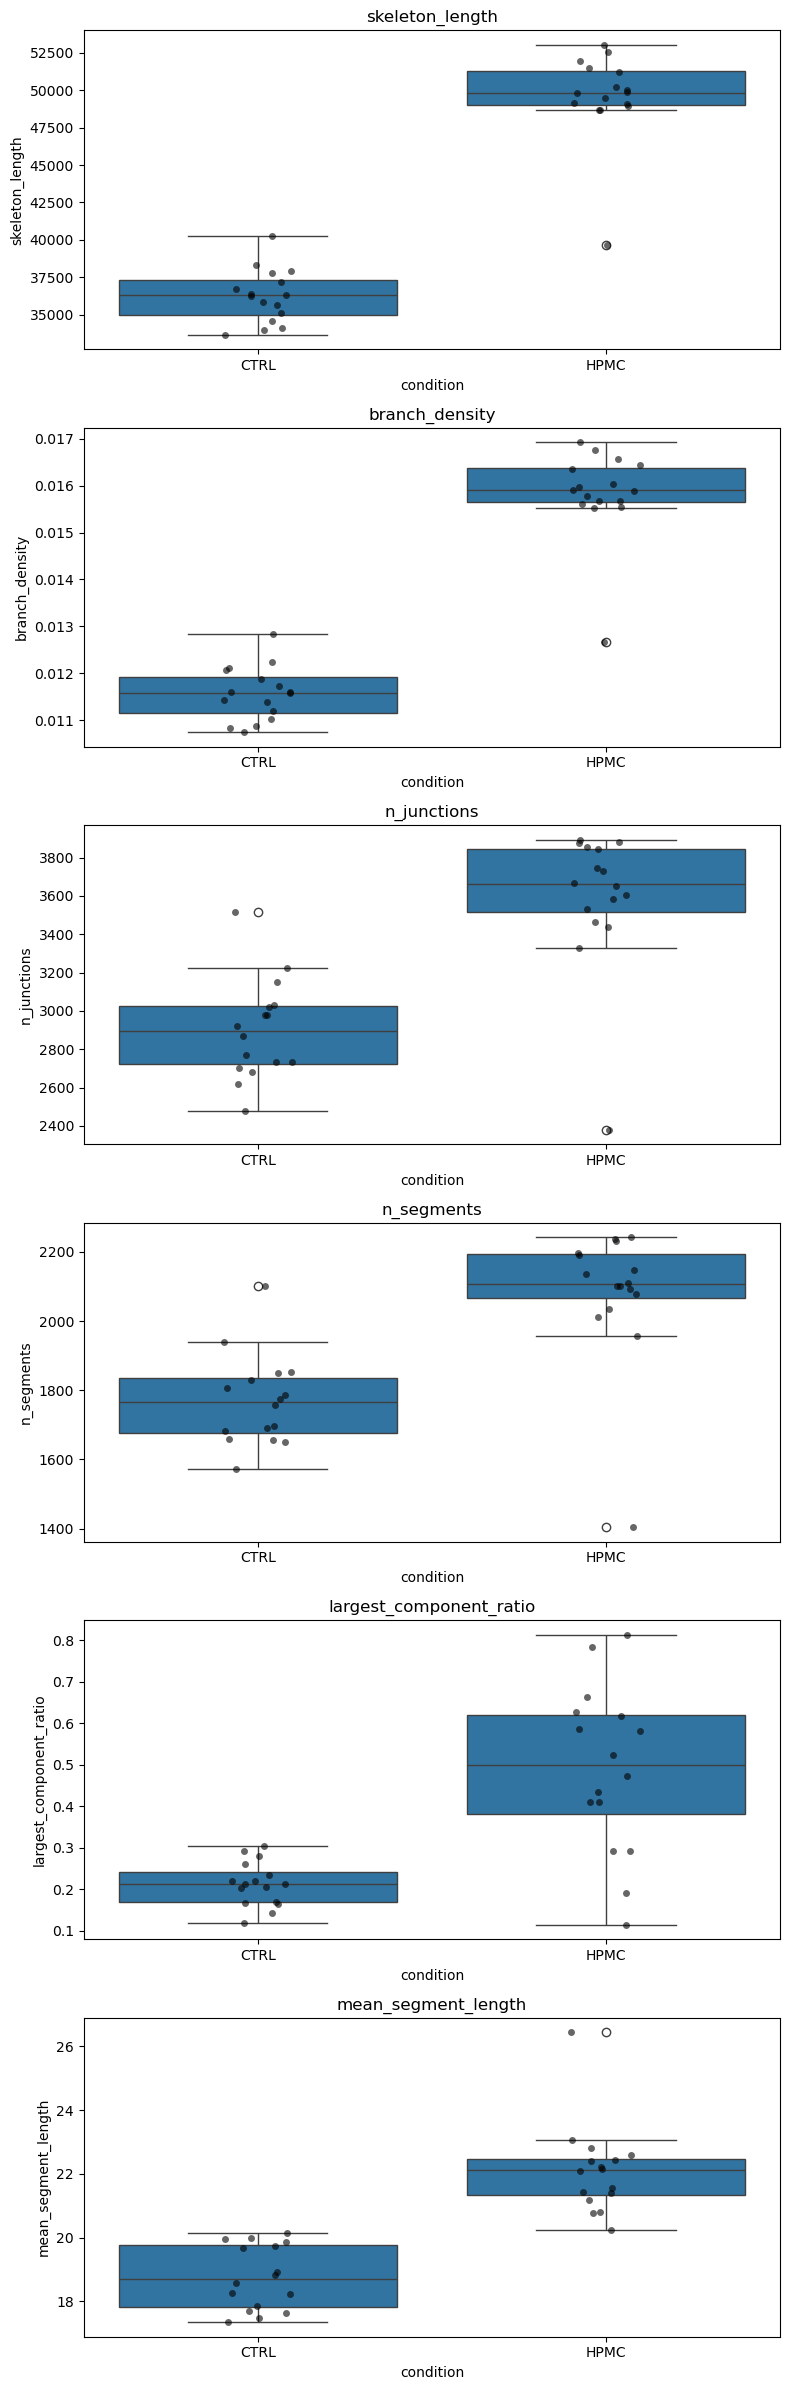

In [10]:
import pandas as pd

df_features = pd.read_csv("features_dataset.csv")

summary = df_features.groupby("condition").mean(numeric_only=True)
print(summary.T)

# VISUALIZAMOS FEATURES
from pipeline import plot_feature_boxplots

plot_feature_boxplots(df_features, [
    "skeleton_length",
    "branch_density",
    "n_junctions",
    "n_segments",
    "largest_component_ratio",
    "mean_segment_length"
])

In [1]:
import pandas as pd
from src.features import rank_features, print_report

df_features = pd.read_csv("features_dataset.csv")

results = rank_features(df_features)
print_report(results, top_n=15)

results.to_csv("feature_ranking_results.csv", index=False)

  FEATURE IMPORTANCE REPORT  (top 15)
 rank                 feature importance_tier  composite_score_norm effect_size  sig_ttest  sig_mwu
    1        median_thickness          🔴 HIGH             99.421160       large       True     True
    2         skeleton_length          🔴 HIGH             99.164790       large       True     True
    3          branch_density          🔴 HIGH             99.164790       large       True     True
    4          mean_thickness          🔴 HIGH             88.238856       large       True     True
    5       median_tortuosity          🔴 HIGH             74.521151       large       True     True
    6   median_segment_length          🔴 HIGH             67.103681       large       True     True
    7     mean_segment_length          🔴 HIGH             63.632118       large       True     True
    8      std_segment_length          🔴 HIGH             58.562606       large       True     True
    9   median_component_area          🔴 HIGH             57.0

Reducir el dataset a un conjunto de features que sea:
- informativo
- poco redundante
- estable
- útil para clasificar CTRL vs HPMC